In [ ]:
"""Title:
Handwritten Character Recognition using CNN

Objective:
To recognize handwritten English characters using a Convolutional Neural Network (CNN). The model is trained on the EMNIST dataset and predicts handwritten characters with high accuracy."""

In [ ]:
!pip uninstall -y tensorflow-datasets
!pip install -U tensorflow tensorflow-datasets

Found existing installation: tensorflow-datasets 4.9.10
Uninstalling tensorflow-datasets-4.9.10:
  Successfully uninstalled tensorflow-datasets-4.9.10
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 68.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 74.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 20.7 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.20.0
    Uninstalling tensorflow-2.20.0:
      Successfully uninstalled tensorflow-2.20.0
ERROR: pip's dependency resolver does not currently t

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds

print("TensorFlow:", tf.__version__)
print("TFDS:", tfds.__version__)
print(hasattr(tfds, "load"))

TensorFlow: 2.21.0
TFDS: 4.9.10
True


In [ ]:
(ds_train, ds_test), ds_info = tfds.load(
    "emnist/letters",
    split=["train", "test"],
    as_supervised=True,
    with_info=True
)

print(ds_info)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.2HB2V7_3.1.0/emnist-train.tfrecord-[0-9][0-9][0-…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.2HB2V7_3.1.0/emnist-test.tfrecord-[0-9][0-9][0-9…

Dataset emnist downloaded and prepared to /root/tensorflow_datasets/emnist/letters/3.1.0. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='emnist',
    full_name='emnist/letters/3.1.0',
    description="""
    The EMNIST dataset is a set of handwritten character digits derived from the NIST Special Database 19 and converted to a 28x28 pixel image format and dataset structure that directly matches the MNIST dataset.
    
    Note: Like the original EMNIST data, images provided here are inverted horizontally and rotated 90 anti-clockwise. You can use `tf.transpose` within `ds.map` to convert the images to a human-friendlier format.
    """,
    config_description="""
    EMNIST Letters
    """,
    homepage='https://www.nist.gov/itl/products-and-services/emnist-dataset',
    data_dir='/root/tensorflow_datasets/emnist/letters/3.1.0',
    file_format=tfrecord,
    download_size=535.73 MiB,
    dataset_size=44.14 MiB,
    features=FeaturesDict({
        'image': Image

In [ ]:
import tensorflow as tf

BATCH_SIZE = 64

def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0

    # Fix EMNIST orientation
    image = tf.transpose(image, perm=[1, 0, 2])
    image = tf.image.flip_left_right(image)

    return image, label

train_ds = ds_train.map(preprocess)
test_ds = ds_test.map(preprocess)

train_ds = train_ds.shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Dataset Ready!")

Dataset Ready!


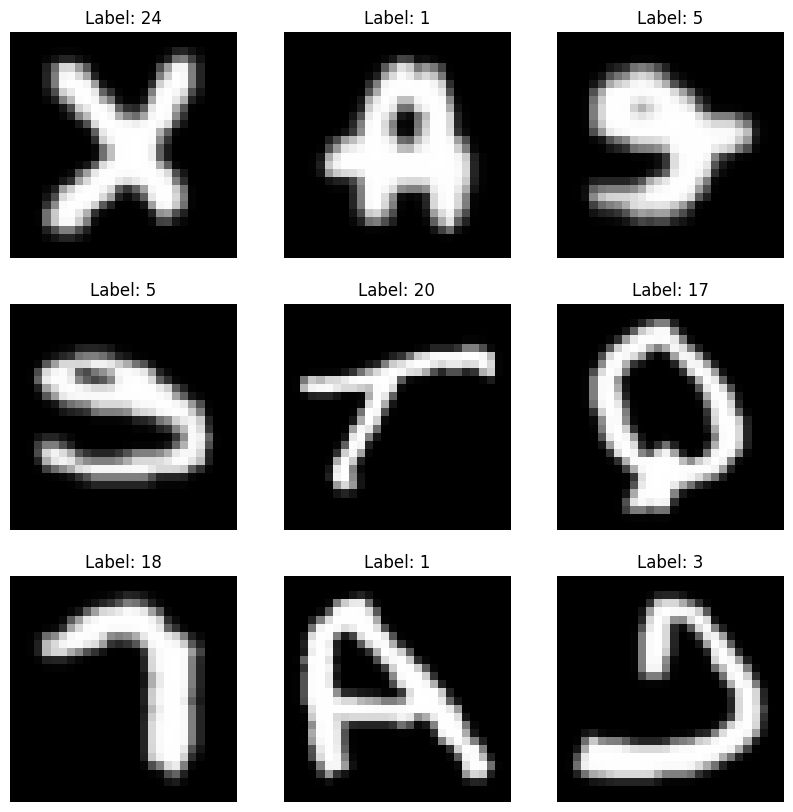

In [ ]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_ds))

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().squeeze(), cmap="gray")
    plt.title(f"Label: {labels[i].numpy()}")
    plt.axis("off")

plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential([

    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128,activation='relu'),

    Dropout(0.4),

    Dense(37,activation='softmax')

])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 37)             │         4,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 228,517 (892.64 KB)

 Trainable params: 228,517 (892.64 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10
)

Epoch 1/10
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 105s 75ms/step - accuracy: 0.9360 - loss: 0.1797 - val_accuracy: 0.9255 - val_loss: 0.2316
Epoch 2/10
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 129s 65ms/step - accuracy: 0.9389 - loss: 0.1704 - val_accuracy: 0.9264 - val_loss: 0.2354
Epoch 3/10
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9419 - loss: 0.1603

KeyboardInterrupt: 

In [ ]:
loss, accuracy = model.evaluate(test_ds)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

232/232 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9248 - loss: 0.2329
Test Loss: 0.23288778960704803
Test Accuracy: 0.9247972965240479


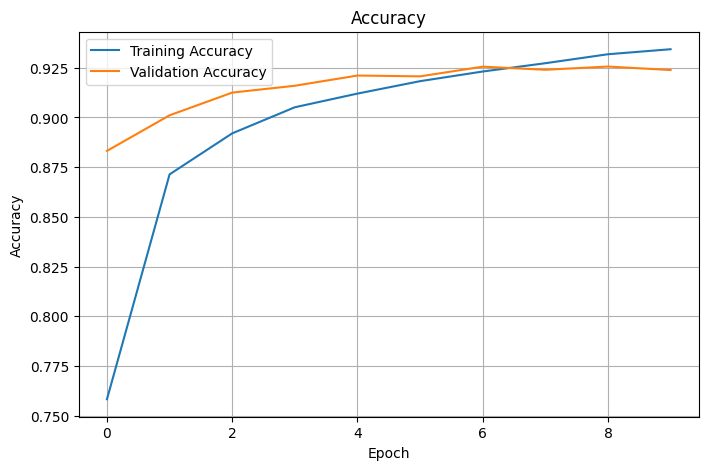

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

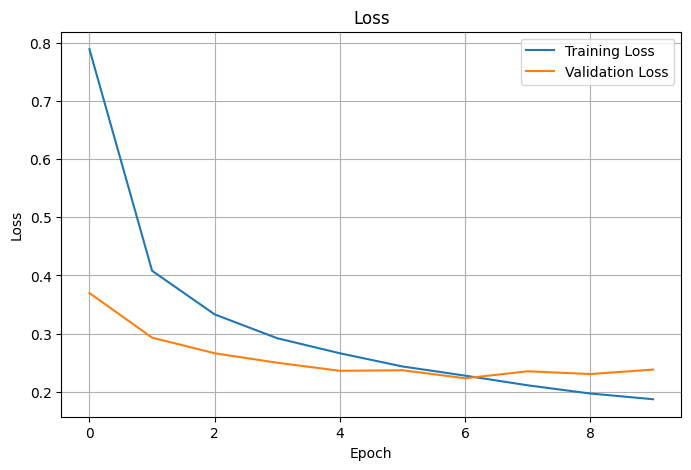

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
model.save("handwritten_character_recognition.keras")

print("Model Saved Successfully!")

Model Saved Successfully!


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step


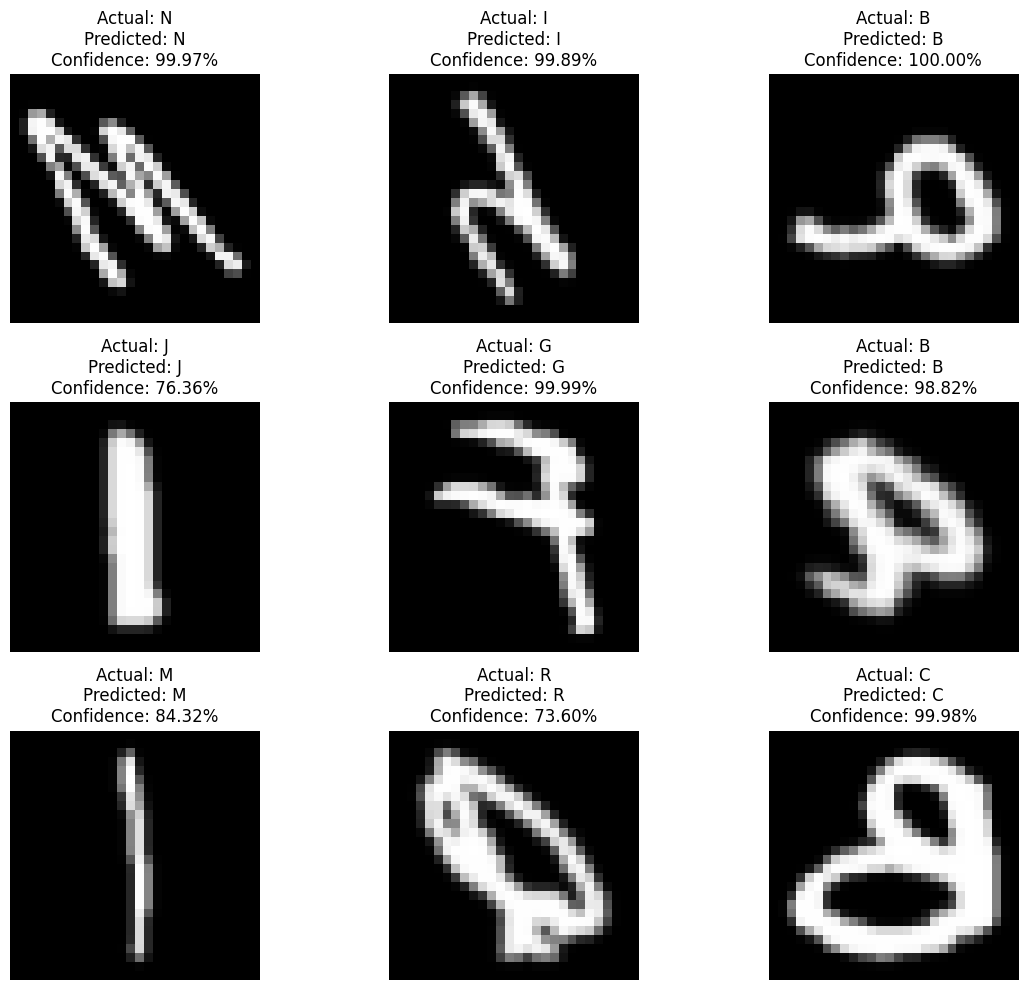

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import string

letters = list(string.ascii_uppercase)

images, labels = next(iter(test_ds))

predictions = model.predict(images)

predicted_classes = np.argmax(predictions, axis=1)
confidence = np.max(predictions, axis=1) * 100

plt.figure(figsize=(12,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i].numpy().squeeze(), cmap='gray')

    pred = predicted_classes[i]
    actual = labels[i].numpy()

    # Map class numbers to letters
    if pred < 26:
        pred_letter = letters[pred]
    else:
        pred_letter = f"Class {pred}"

    if actual < 26:
        actual_letter = letters[actual]
    else:
        actual_letter = f"Class {actual}"

    plt.title(f"Actual: {actual_letter}\nPredicted: {pred_letter}\nConfidence: {confidence[i]:.2f}%")

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import string

letters = list(string.ascii_uppercase)

images, labels = next(iter(test_ds))

prediction = model.predict(images)

predicted_class = np.argmax(prediction[0])
confidence = np.max(prediction[0]) * 100

if predicted_class < 26:
    predicted_character = letters[predicted_class]
else:
    predicted_character = f"Class {predicted_class}"

print("Predicted Character:", predicted_character)
print("Confidence: {:.2f}%".format(confidence))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predicted Character: N
Confidence: 99.97%


In [ ]:
"""Conclusion:

The Handwritten Character Recognition system was successfully implemented using a Convolutional Neural Network (CNN). The model was trained on the EMNIST dataset and achieved approximately 93% training accuracy and 92% validation accuracy. The trained model is capable of recognizing handwritten characters with high confidence and can be extended for recognizing complete words and sentences using advanced sequence models such as CRNN."""